In [2]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_ROOT = Path(r"C:\Users\athar\AI Projects\Li-Ion-Battery-Reliability-Degradation-Analytics")
os.chdir(PROJECT_ROOT)


In [4]:
features = pd.read_parquet("data/processed/battery_features.parquet")

print(features.shape)
features.head()

(2654, 34)


,cell_id,discharge_cycle,cycle_index,capacity_ah,voltage_start,voltage_end,voltage_min,voltage_mean,current_mean,temp_max,...,capacity_roll_mean_5,failure_cycle,rul,eol_reached,time_to_3v,voltage_slope,temp_rise,temp_roll_mean_5,Re,Rct
0,1. BatteryAgingARC-FY08Q4_B0005,1,1,1.856487,4.191492,3.277170,2.612467,3.529829,-1.818702,38.982181,...,1.856487,162,161,False,3287.969,-0.000248,14.652147,38.982181,NaN,NaN
1,1. BatteryAgingARC-FY08Q4_B0005,2,3,1.846327,4.189773,3.300245,2.587209,3.537320,-1.817560,39.033398,...,1.851407,162,160,False,3269.688,-0.000242,14.335646,39.007790,NaN,NaN
2,1. BatteryAgingARC-FY08Q4_B0005,3,5,1.835349,4.188187,3.327451,2.651917,3.543737,-1.816487,38.818797,...,1.846055,162,159,False,3250.437,-0.000236,14.084531,38.944792,NaN,NaN
3,1. BatteryAgingARC-FY08Q4_B0005,4,7,1.835263,4.188461,3.314182,2.592948,3.543666,-1.825589,38.762305,...,1.843357,162,158,False,3250.563,-0.000241,14.108068,38.899170,NaN,NaN
4,1. BatteryAgingARC-FY08Q4_B0005,5,9,1.834646,4.188299,3.305497,2.547420,3.542343,-1.826114,38.665393,...,1.841614,162,157,False,3248.766,-0.000243,14.140596,38.852415,NaN,NaN


In [5]:
print("Number of cells:", features["cell_id"].nunique())

print("\nCells:")
print(sorted(features["cell_id"].unique()))

print("\nMissing values:")
print(features.isna().sum())

print("\nDataset info:")
features.info()

Number of cells: 38

Cells:
['1. BatteryAgingARC-FY08Q4_B0005', '1. BatteryAgingARC-FY08Q4_B0006', '1. BatteryAgingARC-FY08Q4_B0007', '1. BatteryAgingARC-FY08Q4_B0018', '2. BatteryAgingARC_25_26_27_28_P1_B0025', '2. BatteryAgingARC_25_26_27_28_P1_B0026', '2. BatteryAgingARC_25_26_27_28_P1_B0027', '2. BatteryAgingARC_25_26_27_28_P1_B0028', '3. BatteryAgingARC_25-44_B0025', '3. BatteryAgingARC_25-44_B0026', '3. BatteryAgingARC_25-44_B0027', '3. BatteryAgingARC_25-44_B0028', '3. BatteryAgingARC_25-44_B0029', '3. BatteryAgingARC_25-44_B0030', '3. BatteryAgingARC_25-44_B0031', '3. BatteryAgingARC_25-44_B0032', '3. BatteryAgingARC_25-44_B0033', '3. BatteryAgingARC_25-44_B0034', '3. BatteryAgingARC_25-44_B0036', '3. BatteryAgingARC_25-44_B0038', '3. BatteryAgingARC_25-44_B0039', '3. BatteryAgingARC_25-44_B0040', '3. BatteryAgingARC_25-44_B0041', '3. BatteryAgingARC_25-44_B0042', '3. BatteryAgingARC_25-44_B0043', '3. BatteryAgingARC_25-44_B0044', '4. BatteryAgingARC_45_46_47_48_B0045', '4. Bat

Findings:
- The dataset contains multiple Li-ion battery cells tested under controlled laboratory conditions.
- Each row represents a discharge cycle for a specific battery.
- The engineered dataset includes degradation, thermal, voltage, impedance, and RUL-related features.
- Some impedance measurements (Re, Rct) contain missing values because impedance tests were not conducted for every discharge cycle.
- The dataset appears structurally consistent and suitable for downstream reliability and ML modeling.


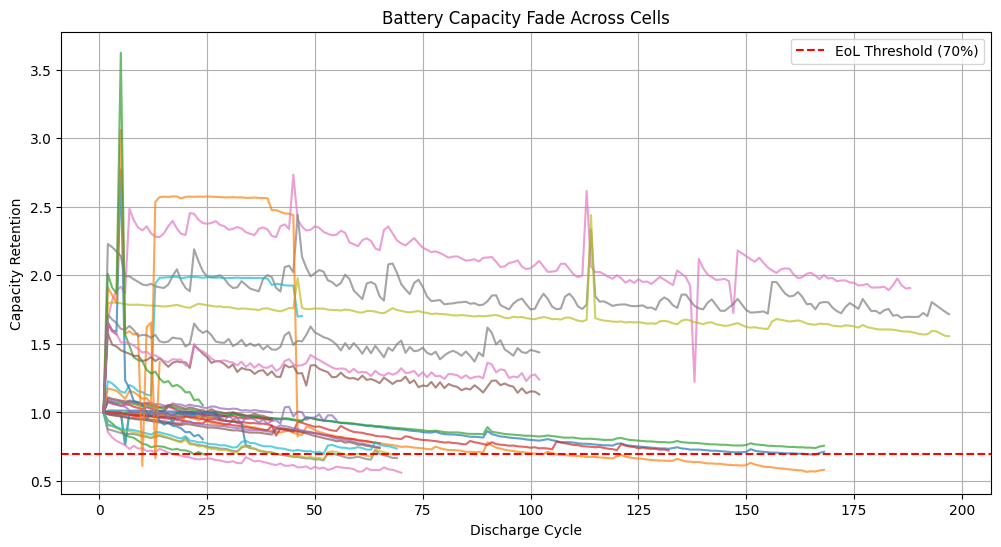

In [14]:
plt.figure(figsize=(12, 6))

for cell_id, group in features.groupby("cell_id"):
    plt.plot(
        group["discharge_cycle"].to_numpy(),
        group["capacity_retention"].to_numpy(),
        alpha=0.7
    )

plt.axhline(
    y=0.70,
    color="red",
    linestyle="--",
    label="EoL Threshold (70%)"
)

plt.xlabel("Discharge Cycle")
plt.ylabel("Capacity Retention")
plt.title("Battery Capacity Fade Across Cells")

plt.legend()
plt.grid(True)

plt.show()

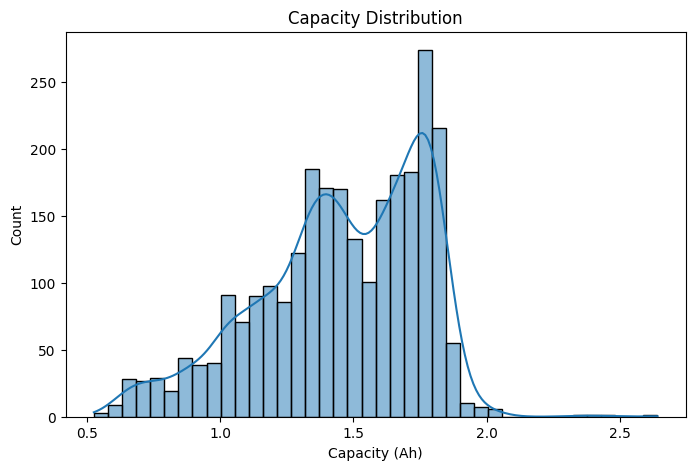

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    features["capacity_ah"].to_numpy(),
    bins=40,
    kde=True
)

plt.xlabel("Capacity (Ah)")
plt.title("Capacity Distribution")

plt.show()

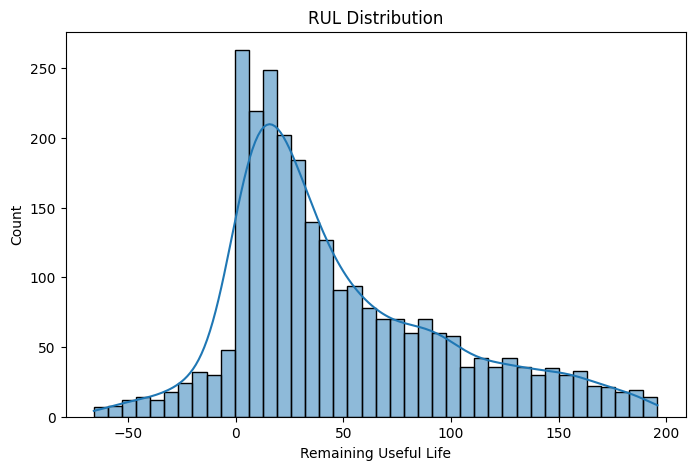

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    features["rul"],
    bins=40,
    kde=True
)

plt.xlabel("Remaining Useful Life")
plt.title("RUL Distribution")

plt.show()

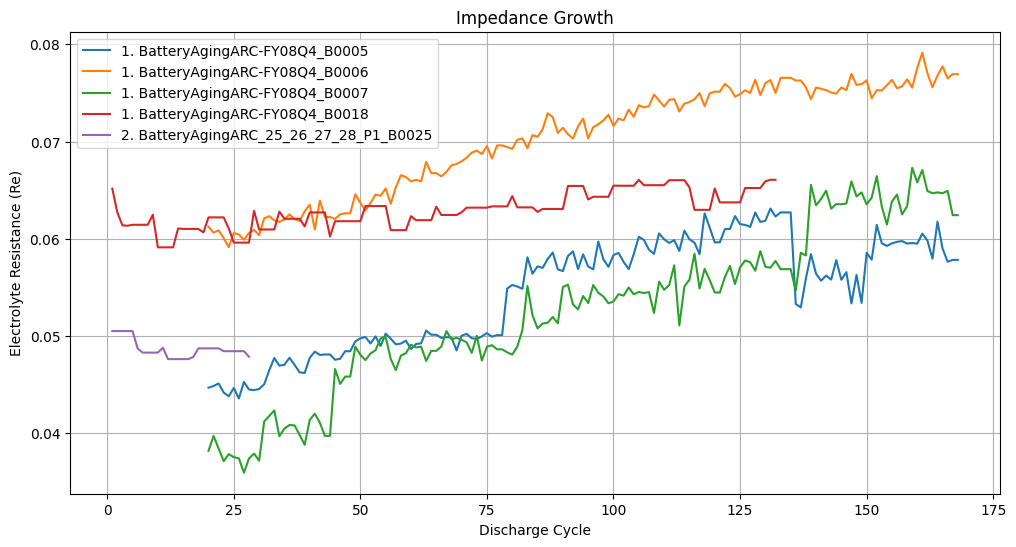

In [9]:
sample_cells = features["cell_id"].unique()[:5]

plt.figure(figsize=(12, 6))

for cell in sample_cells:
    subset = features[
        (features["cell_id"] == cell) &
        (~features["Re"].isna())
    ]

    plt.plot(
        subset["discharge_cycle"],
        subset["Re"],
        label=cell
    )

plt.xlabel("Discharge Cycle")
plt.ylabel("Electrolyte Resistance (Re)")
plt.title("Impedance Growth")

plt.legend()
plt.grid(True)

plt.show()

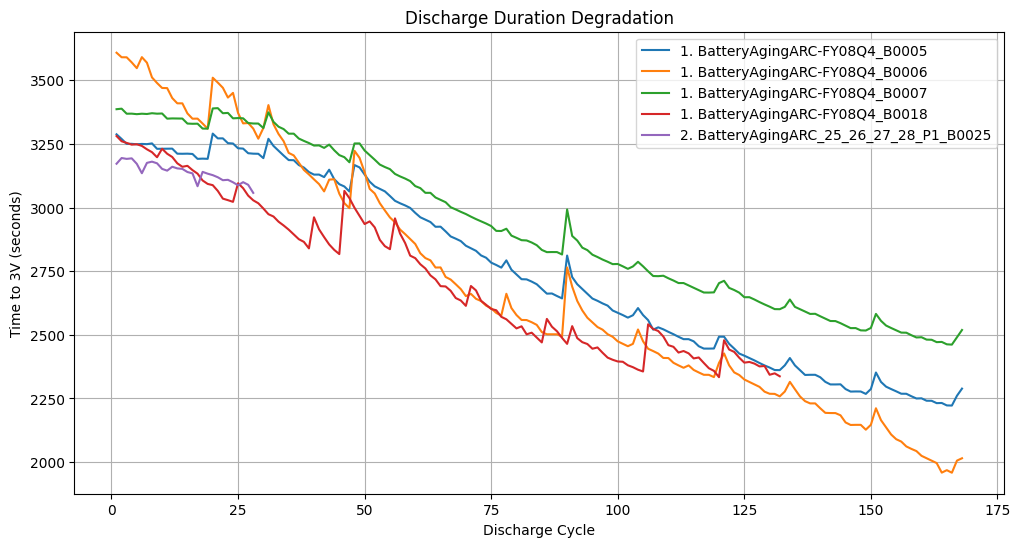

In [10]:
plt.figure(figsize=(12, 6))

for cell in sample_cells:
    subset = features[features["cell_id"] == cell]

    plt.plot(
        subset["discharge_cycle"],
        subset["time_to_3v"],
        label=cell
    )

plt.xlabel("Discharge Cycle")
plt.ylabel("Time to 3V (seconds)")
plt.title("Discharge Duration Degradation")

plt.legend()
plt.grid(True)

plt.show()

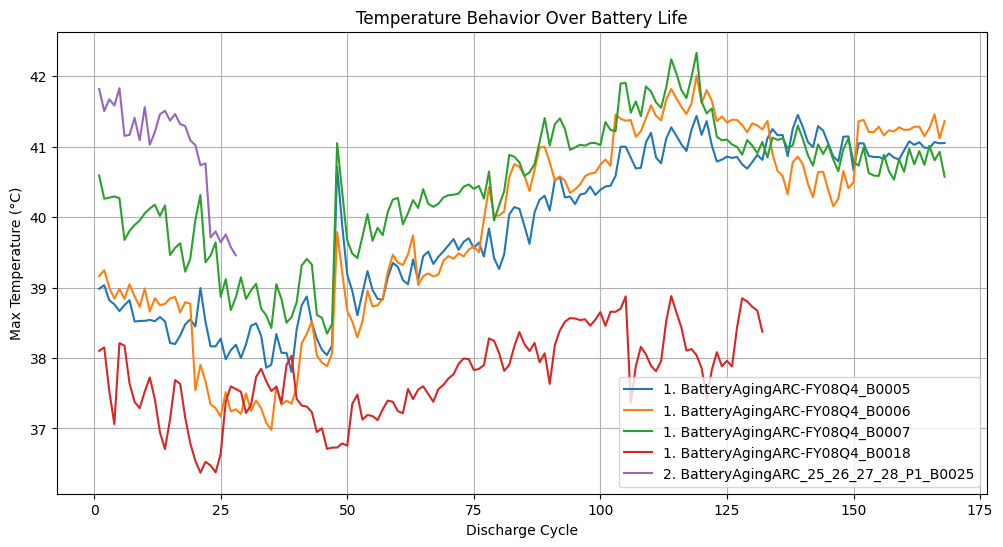

In [11]:
plt.figure(figsize=(12, 6))

for cell in sample_cells:
    subset = features[features["cell_id"] == cell]

    plt.plot(
        subset["discharge_cycle"],
        subset["temp_max"],
        label=cell
    )

plt.xlabel("Discharge Cycle")
plt.ylabel("Max Temperature (°C)")
plt.title("Temperature Behavior Over Battery Life")

plt.legend()
plt.grid(True)

plt.show()

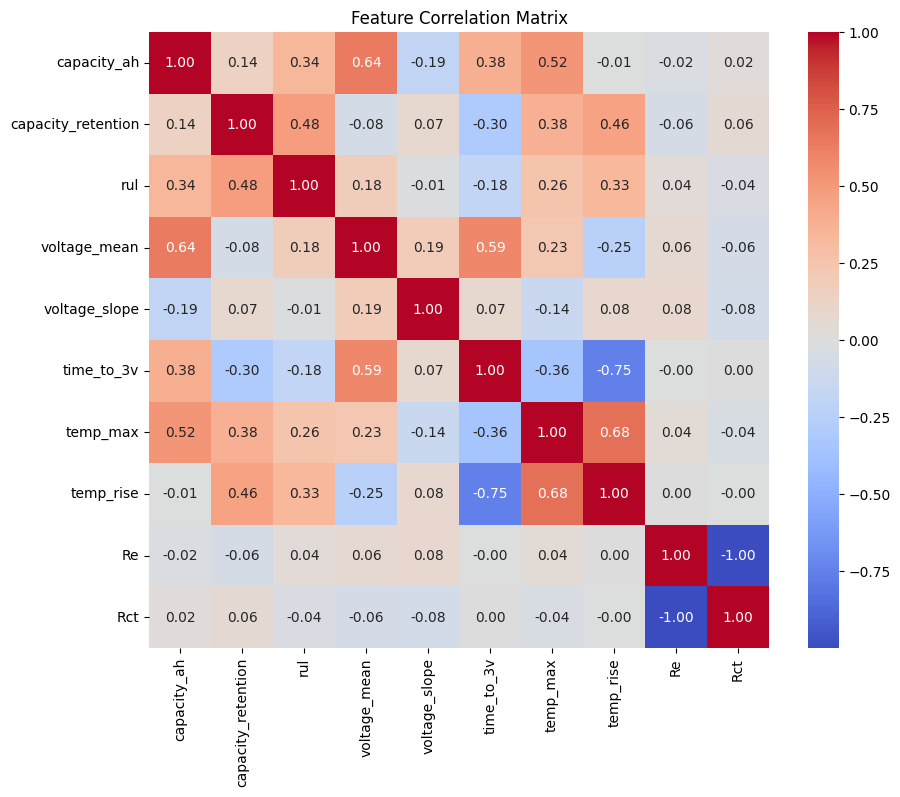

In [12]:
corr_features = [
    "capacity_ah",
    "capacity_retention",
    "rul",
    "voltage_mean",
    "voltage_slope",
    "time_to_3v",
    "temp_max",
    "temp_rise",
    "Re",
    "Rct"
]

corr = features[corr_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

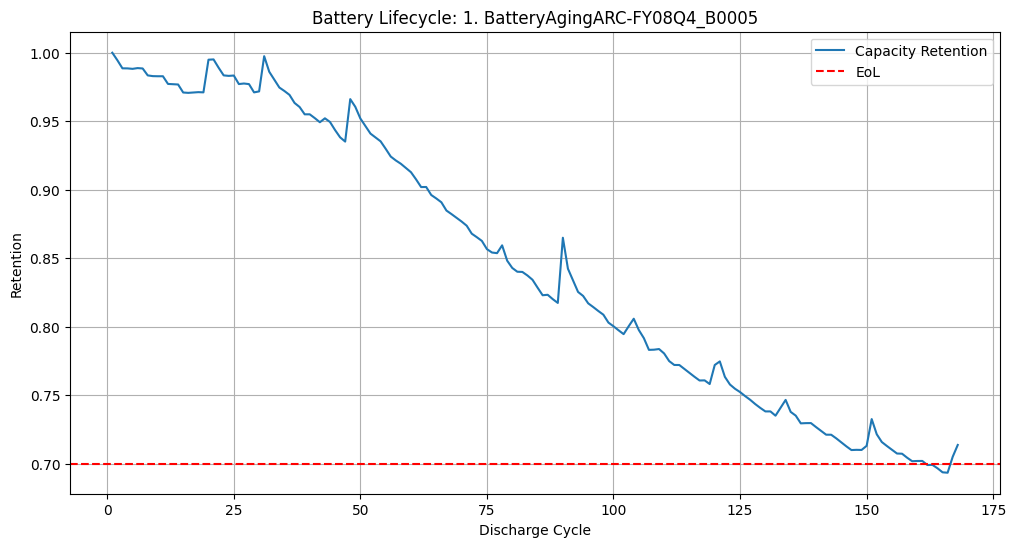

In [13]:
cell = "1. BatteryAgingARC-FY08Q4_B0005"

subset = features[features["cell_id"] == cell]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    subset["discharge_cycle"],
    subset["capacity_retention"],
    label="Capacity Retention"
)

ax.axhline(
    0.70,
    color="red",
    linestyle="--",
    label="EoL"
)

ax.set_xlabel("Discharge Cycle")
ax.set_ylabel("Retention")

ax.set_title(f"Battery Lifecycle: {cell}")

ax.legend()
ax.grid(True)

plt.show()

Overall EDA Conclusions:
- The dataset exhibits realistic lithium-ion battery degradation behavior.
- Capacity fade, impedance growth, voltage degradation, and thermal changes are all observable across battery lifecycles.
- The engineered features successfully capture both electrochemical and operational ageing characteristics.
- The dataset is well-suited for:
    1. Reliability analysis using Weibull survival modeling
    2. Remaining Useful Life (RUL) forecasting
    3. Predictive maintenance analytics
- No major structural or physical inconsistencies were identified during exploratory analysis.
- The next stage will focus on population-level reliability modeling and ML-based RUL forecasting.